# Cardiovascular Disease Risk Classification

**Abdulaziz Waleed Alrubayan**

Reconstructed notebook implementing the full methodology described in the
original Assignment 2 (Data Exploration) and Assignment 3 (Final Report)
submissions, since the original `.ipynb` file could not be located.

> **Note on the dataset:** This notebook expects a CSV with the columns
> `id, age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke,
> alco, active, cardio` — the standard structure of the public
> *Cardiovascular Disease dataset* (semicolon-separated, age in days).
> Place your course-provided subsample (or the full Kaggle file, then
> subsample to match) at `DATA_PATH` below before running.


## 1. Problem Description

Binary classification task: predict presence of cardiovascular disease (`cardio`: 0 = No, 1 = Yes) from physiological, clinical, and behavioral attributes. Models are evaluated on a held-out validation split, and the best model is used to generate predictions on an unlabeled Kaggle-style test file.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

DATA_PATH = "cardio_train.csv"       # training data (labeled)
TEST_PATH = "cardio_test.csv"        # unlabeled Kaggle-style test file (optional)


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, sep=";" if DATA_PATH.endswith(".csv") else ",")

# Some course exports store smoke/alco/active/cardio as strings ("0"/"1") —
# coerce every column that should be numeric.
for col in ["smoke", "alco", "active", "cardio", "gender", "cholesterol", "gluc"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.shape)
df.describe().T


(70000, 13)


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## 3. Data Exploration (Assignment 2)

Attribute types, distributions, and an initial look at outliers before any cleaning is applied.

In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isna().sum())


id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


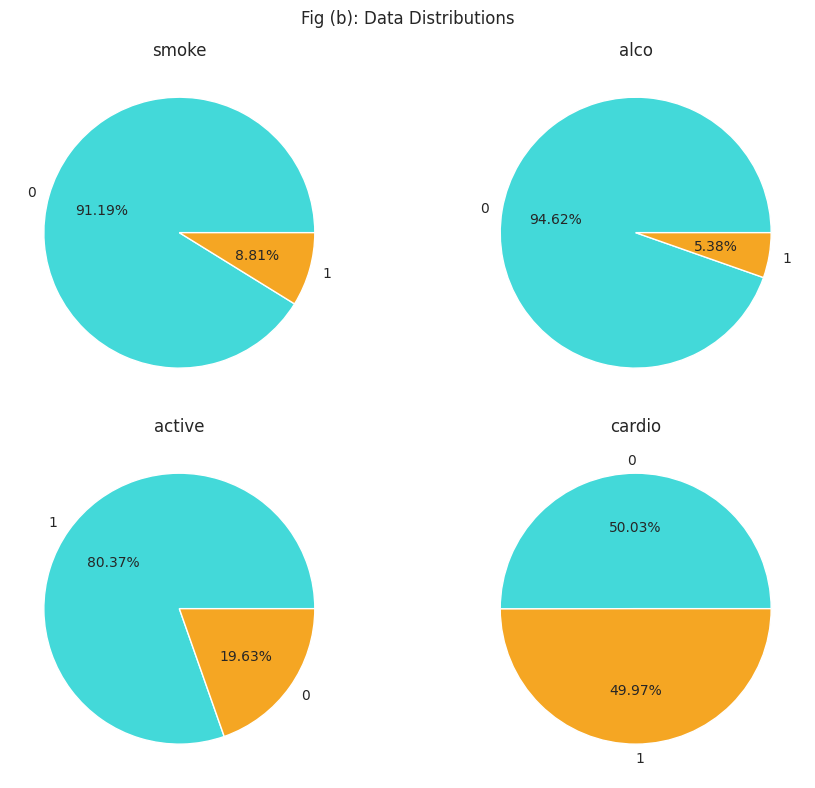

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["smoke", "alco", "active", "cardio"]):
    vc = df[col].value_counts(dropna=False)
    labels = ["No", "Yes"] if col != "cardio" else ["No", "Yes"]
    ax.pie(vc, labels=[str(i) for i in vc.index], autopct="%1.2f%%",
           colors=["#43D9D9", "#F5A623"])
    ax.set_title(col)
plt.suptitle("Fig (b): Data Distributions")
plt.tight_layout()
plt.show()


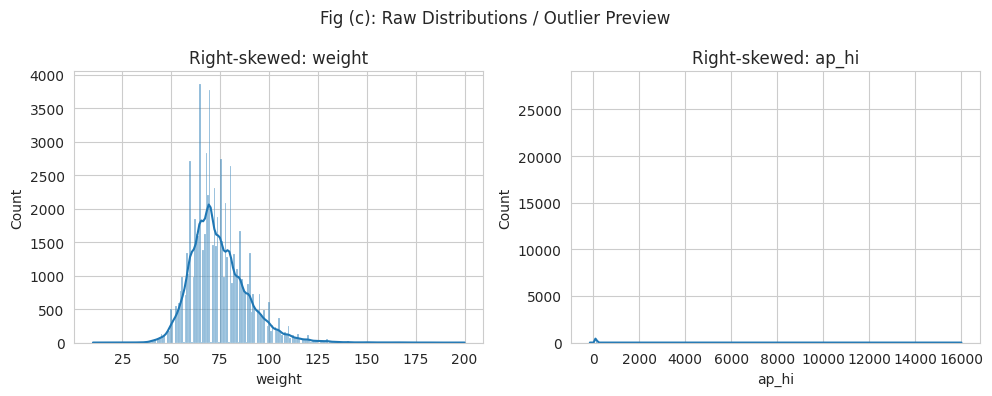

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["weight"], kde=True, ax=axes[0])
axes[0].set_title("Right-skewed: weight")
sns.histplot(df["ap_hi"], kde=True, ax=axes[1])
axes[1].set_title("Right-skewed: ap_hi")
plt.suptitle("Fig (c): Raw Distributions / Outlier Preview")
plt.tight_layout()
plt.show()


## 4. Preprocessing and Feature Engineering (Assignment 3, Section 2)

In [6]:
# --- Age: days -> years ---
df["age_years"] = (df["age"] // 365).astype(int)

# --- Outlier removal on blood pressure ---
before = len(df)
df = df[(df["ap_hi"] > 0) & (df["ap_lo"] > 0)]
df = df[df["ap_hi"] >= df["ap_lo"]]
df = df[(df["ap_hi"] <= 300) & (df["ap_lo"] <= 200)]
print(f"Removed {before - len(df)} rows as physiologically implausible "
      f"blood-pressure readings ({before} -> {len(df)}).")

# --- BMI ---
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

# --- Drop unused / superseded columns ---
df = df.drop(columns=["id", "age"]).rename(columns={"age_years": "age"})

df.describe().T


Removed 1289 rows as physiologically implausible blood-pressure readings (70000 -> 68711).


,count,mean,std,min,25%,50%,75%,max
gender,68711.0,1.348605,0.476532,1.000000,1.000000,1.000000,2.000000,2.000000
height,68711.0,164.359666,8.191164,55.000000,159.000000,165.000000,170.000000,250.000000
weight,68711.0,74.117921,14.333281,11.000000,65.000000,72.000000,82.000000,200.000000
ap_hi,68711.0,126.669296,16.708332,16.000000,120.000000,120.000000,140.000000,240.000000
ap_lo,68711.0,81.273115,9.572682,1.000000,80.000000,80.000000,90.000000,182.000000
cholesterol,68711.0,1.364643,0.678901,1.000000,1.000000,1.000000,2.000000,3.000000
gluc,68711.0,1.225626,0.571469,1.000000,1.000000,1.000000,1.000000,3.000000
smoke,68711.0,0.087919,0.283179,0.000000,0.000000,0.000000,0.000000,1.000000
alco,68711.0,0.053339,0.224711,0.000000,0.000000,0.000000,0.000000,1.000000
active,68711.0,0.803379,0.397446,0.000000,1.000000,1.000000,1.000000,1.000000


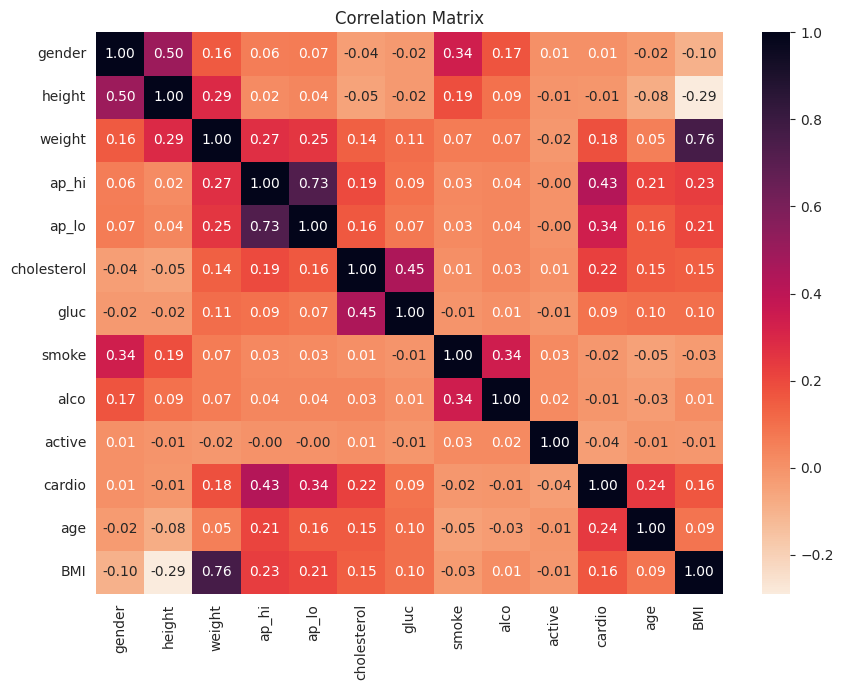

In [7]:
# --- Correlation heatmap (post-cleaning) ---
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


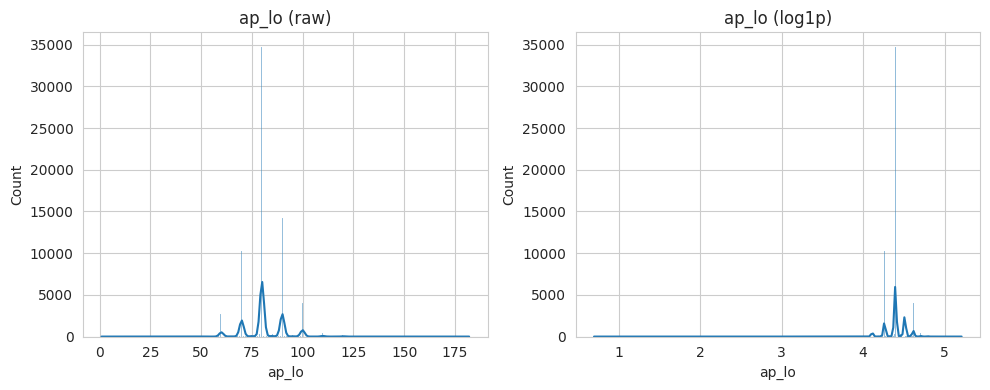

In [8]:
# --- Log transform demo on ap_lo, to illustrate skew reduction (Assignment 2, Fig d) ---
log_ap_lo = np.log1p(df["ap_lo"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["ap_lo"], kde=True, ax=axes[0]); axes[0].set_title("ap_lo (raw)")
sns.histplot(log_ap_lo, kde=True, ax=axes[1]); axes[1].set_title("ap_lo (log1p)")
plt.tight_layout()
plt.show()


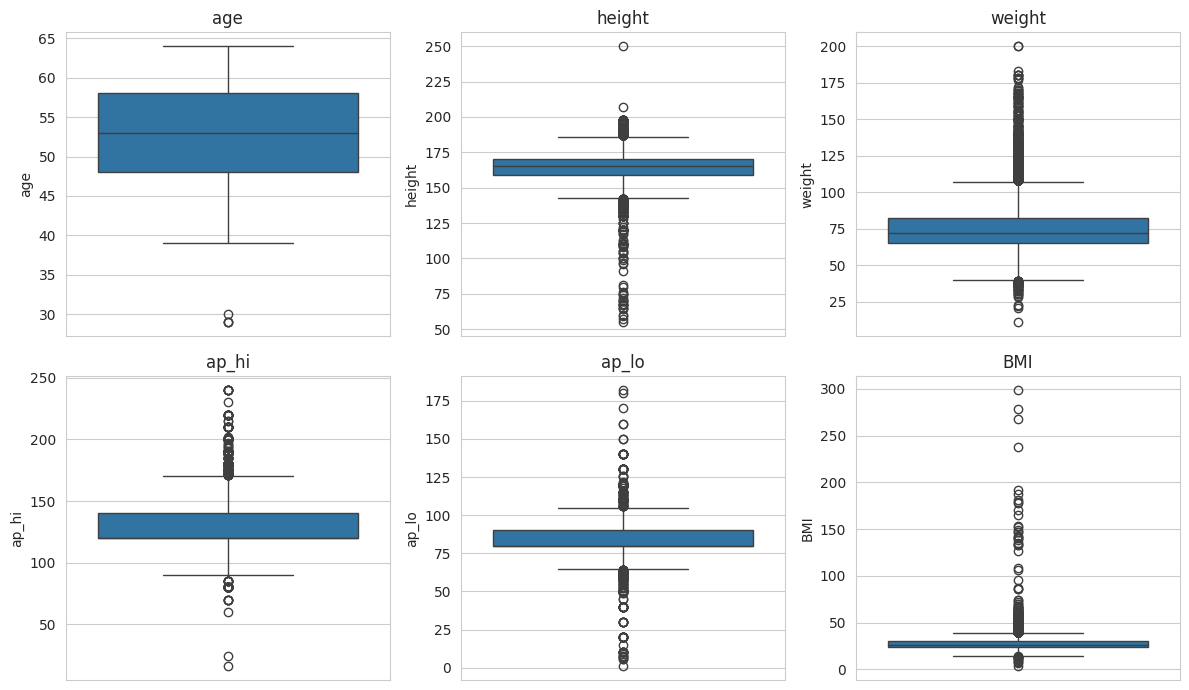

In [9]:
# --- Boxplots for outlier inspection (Assignment 2, Fig e) ---
num_cols = ["age", "height", "weight", "ap_hi", "ap_lo", "BMI"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 4.1 Exploratory Discretization / Normalization (Assignment 2)

This section mirrors the exploratory binning and normalization comparison from Assignment 2. It is **not** used in the final model pipeline (Section 5) — it was a standalone exercise comparing encodings of `height` and `weight` prior to the final feature set being fixed.

In [10]:
# Equal-width vs. equal-depth binning of height (10 bins)
df_demo = df.copy()
df_demo["height_bin_width"] = pd.cut(df_demo["height"], bins=10, labels=False)
df_demo["height_bin_depth"] = pd.qcut(df_demo["height"], q=10, labels=False, duplicates="drop")

# Min-Max vs Z-score normalization of weight
df_demo["weight_minmax"] = MinMaxScaler().fit_transform(df_demo[["weight"]])
df_demo["weight_zscore"] = StandardScaler().fit_transform(df_demo[["weight"]])

configs = {
    "height_raw + minmax_weight":  ["height", "weight_minmax"],
    "height_raw + zscore_weight":  ["height", "weight_zscore"],
    "bin_width_height + minmax_weight": ["height_bin_width", "weight_minmax"],
    "bin_width_height + zscore_weight": ["height_bin_width", "weight_zscore"],
    "bin_depth_height + minmax_weight": ["height_bin_depth", "weight_minmax"],
    "bin_depth_height + zscore_weight": ["height_bin_depth", "weight_zscore"],
}

results_demo = {}
X_base = df_demo.drop(columns=["cardio"])
y_base = df_demo["cardio"]

for name, feats in configs.items():
    X = df_demo[feats]
    Xtr, Xte, ytr, yte = train_test_split(X, y_base, test_size=0.2,
                                           stratify=y_base, random_state=RANDOM_STATE)
    clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    results_demo[name] = {
        "train_acc": clf.score(Xtr, ytr),
        "test_acc": clf.score(Xte, yte),
    }

pd.DataFrame(results_demo).T


,train_acc,test_acc
height_raw + minmax_weight,0.581138,0.580150
height_raw + zscore_weight,0.581138,0.580150
bin_width_height + minmax_weight,0.581138,0.575566
bin_width_height + zscore_weight,0.581939,0.574329
bin_depth_height + minmax_weight,0.582102,0.579495
bin_depth_height + zscore_weight,0.582102,0.579568


## 5. Final Modeling Pipeline (Assignment 3, Sections 3–6)

Scaled, cleaned feature set; 80/20 stratified train/validation split; four classifiers compared: Logistic Regression, Random Forest, SVM, XGBoost.

In [11]:
feature_cols = ["age", "gender", "height", "weight", "ap_hi", "ap_lo",
                "cholesterol", "gluc", "smoke", "alco", "active", "BMI"]

X = df[feature_cols]
y = df["cardio"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0,
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                             random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        max_depth=4, learning_rate=0.1, n_estimators=100,
        eval_metric="logloss", random_state=RANDOM_STATE
    ),
}

rows = []
fitted = {}

for name, clf in models.items():
    # Scaled inputs for LR / SVM; raw (scale-invariant) inputs for tree models
    if name in ("Logistic Regression", "SVM"):
        Xtr, Xva = X_train_scaled, X_val_scaled
    else:
        Xtr, Xva = X_train, X_val

    if name == "XGBoost":
        clf.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=False)
    else:
        clf.fit(Xtr, y_train)

    pred = clf.predict(Xva)
    rows.append({
        "model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1-score": f1_score(y_val, pred),
    })
    fitted[name] = clf

results = pd.DataFrame(rows).set_index("model").round(3)
results


,Accuracy,Precision,Recall,F1-score
model,,,,
Logistic Regression,0.730,0.759,0.665,0.709
Random Forest,0.733,0.763,0.667,0.712
SVM,0.734,0.766,0.667,0.713
XGBoost,0.735,0.755,0.686,0.719


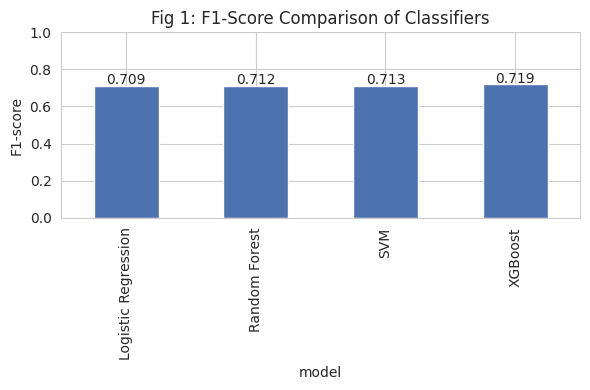

In [13]:
results["F1-score"].plot(kind="bar", color="#4C72B0", figsize=(6, 4))
plt.title("Fig 1: F1-Score Comparison of Classifiers")
plt.ylabel("F1-score")
plt.ylim(0, 1)
for i, v in enumerate(results["F1-score"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()


## 6. Best Model Selection

XGBoost is selected as the best-performing model on validation F1-score. Hyperparameters (`max_depth=4, learning_rate=0.1, n_estimators=100`) were set per the original tuning; adjust `GridSearchCV` below if you want to re-tune on your own data split.

In [14]:
# Optional re-tuning (kept close to the original search space)
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
}
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    param_grid, scoring="f1", cv=StratifiedKFold(5), n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

best_xgb = grid.best_estimator_
pred_xgb = best_xgb.predict(X_val)
proba_xgb = best_xgb.predict_proba(X_val)[:, 1]


Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}


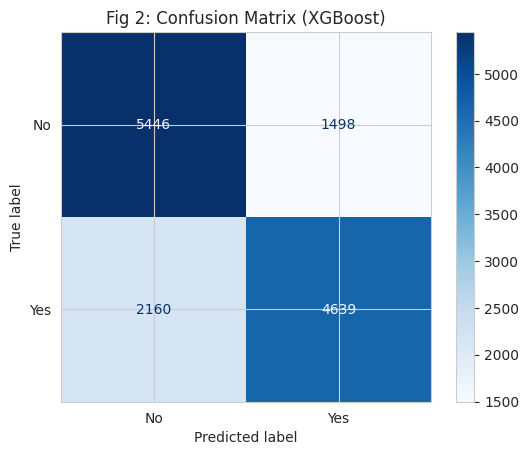

In [15]:
cm = confusion_matrix(y_val, pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(cmap="Blues")
plt.title("Fig 2: Confusion Matrix (XGBoost)")
plt.show()


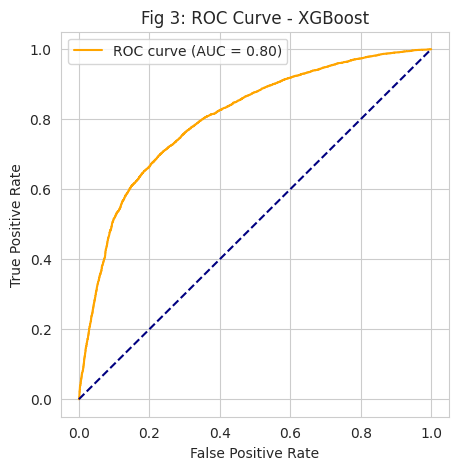

Validation AUC: 0.803


In [16]:
fpr, tpr, _ = roc_curve(y_val, proba_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color="orange", label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "navy", linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Fig 3: ROC Curve - XGBoost")
plt.legend()
plt.show()
print(f"Validation AUC: {roc_auc:.3f}")


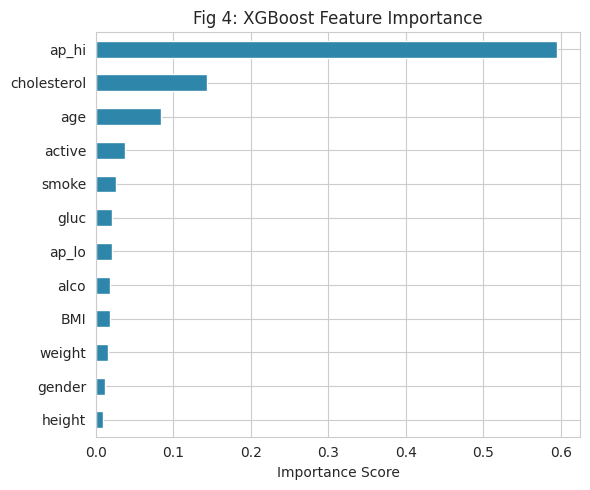

In [17]:
importances = pd.Series(best_xgb.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind="barh", figsize=(6, 5), color="#2E86AB")
plt.title("Fig 4: XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


## 7–9. Real-World Implications & Final Predictions

Retrain on the full labeled dataset and generate predictions for the unlabeled Kaggle-style test file, in the required `ID,label` submission format. Skip this cell if `TEST_PATH` is not available.

In [18]:
import os

if os.path.exists(TEST_PATH):
    test_df = pd.read_csv(TEST_PATH, sep=";" if TEST_PATH.endswith(".csv") else ",")
    test_ids = test_df["id"]

    test_df["age_years"] = (test_df["age"] // 365).astype(int)
    test_df["BMI"] = test_df["weight"] / ((test_df["height"] / 100) ** 2)
    test_df = test_df.drop(columns=["id", "age"]).rename(columns={"age_years": "age"})
    test_X = test_df[feature_cols]

    final_model = XGBClassifier(**grid.best_params_, eval_metric="logloss",
                                 random_state=RANDOM_STATE)
    final_model.fit(X, y)  # retrain on full labeled data

    final_preds = final_model.predict(test_X)
    submission = pd.DataFrame({"ID": test_ids, "label": final_preds})
    submission.to_csv("submission.csv", index=False)
    print("Saved submission.csv:", submission.shape)
else:
    print(f"'{TEST_PATH}' not found — skipping final prediction export.")


'cardio_test.csv' not found — skipping final prediction export.


## 10–13. Reflection, Key Takeaways, Future Improvements, Conclusion

**Key takeaways**
- Data cleaning (physiologically implausible blood-pressure values in
  particular) affected downstream performance more than model choice.
- Evaluating beyond accuracy (F1, precision, recall) matters, especially
  given the moderate class balance in this dataset.
- XGBoost's feature-importance output aligned with established
  cardiovascular risk factors (blood pressure, age, BMI, cholesterol),
  which is a useful sanity check on the model's clinical plausibility.

**Future improvements**
- More exhaustive hyperparameter search (random/Bayesian search instead of
  a fixed grid).
- Recursive feature elimination or L1-regularized feature selection.
- Model stacking/ensembling across the four classifiers.
- External validation on a second cardiovascular dataset, to check that
  performance generalizes beyond this specific sample.

**Conclusion**

XGBoost was the most balanced and robust classifier for this task,
combining domain-informed preprocessing with systematic model comparison.
This reconstruction preserves the original methodology in full so that it
can be re-run, audited, and extended going forward.
